# Testing comparison NATIM VS RS

## Import

In [1]:
import os 
os.chdir('/CSNG/studekat/ripple_paper_clean/code')

In [2]:
from functions_analysis import *
import pandas as pd
import numpy as np
import yaml
import pickle
import neo
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations
import matplotlib.patches as mpatches
import matplotlib
from scipy.stats import kruskal, mannwhitneyu

## Parameters

In [3]:
with open("/CSNG/studekat/ripple_paper_clean/code/params_analysis.yml") as f:
    params_analysis = yaml.safe_load(f)

DATA_FOLDER = params_analysis['data_folder'] ### folder with all the preprocessed data
DF_FOLDER = '/CSNG/studekat/ripple_paper_clean/dataframes'

## Data loading

In [4]:
path = f'{DF_FOLDER}/testing_NATIM_RS'
df_RS = pd.read_csv(f'{path}/resting_state_props.csv')
df_NATIM = pd.read_csv(f'{path}/natim_props.csv')

## FR testing - RS EO VS NATIM

In [5]:
# testing at once
down_classes = ['DOWN_narrow_shallow', 'DOWN_medium_shallow', 'DOWN_wide','DOWN_narrow_sharp','DOWN_medium_sharp','UP']

results = []

for cls in down_classes:
    
    RS_vals = df_RS.loc[df_RS['final_class'] == cls,
                        'FR_high_env_low_env_median_ratio_EO']
    
    NATIM_vals = df_NATIM.loc[df_NATIM['final_class'] == cls,
                              'FR_high_env_low_env_median_ratio']
    
    # Mann–Whitney U test (RS < NATIM)
    u_stat, p_val = stats.mannwhitneyu(RS_vals, NATIM_vals, alternative='two-sided')
    
    results.append({
        'class': cls,
        'comparison': 'RS EO vs NATIM',
        'u_stat': u_stat,
        'p_value': p_val,
        'n_RS': len(RS_vals),
        'n_NATIM': len(NATIM_vals),
        'median_RS': RS_vals.median(),
        'median_NATIM': NATIM_vals.median()
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Bonferroni correction
results_df['p_bonf'] = multipletests(results_df['p_value'], method='bonferroni')[1]  # we will plot withou correction, because just RS VS NATIM

results_df


,class,comparison,u_stat,p_value,n_RS,n_NATIM,median_RS,median_NATIM,p_bonf
0,DOWN_narrow_shallow,RS EO vs NATIM,223496.5,3.712009e-27,342,2055,1.218423,1.624264,2.227205e-26
1,DOWN_medium_shallow,RS EO vs NATIM,1349548.0,8.147649e-01,893,3007,1.481267,1.469755,1.000000e+00
2,DOWN_wide,RS EO vs NATIM,800743.0,7.367602e-03,492,3517,1.548889,1.651102,4.420561e-02
3,DOWN_narrow_sharp,RS EO vs NATIM,185668.0,1.977661e-03,206,1592,1.173489,1.120938,1.186597e-02
4,DOWN_medium_sharp,RS EO vs NATIM,145848.0,3.235373e-01,225,1245,1.221378,1.190234,1.000000e+00
5,UP,RS EO vs NATIM,4660.0,1.739681e-01,28,288,1.726547,1.299853,1.000000e+00


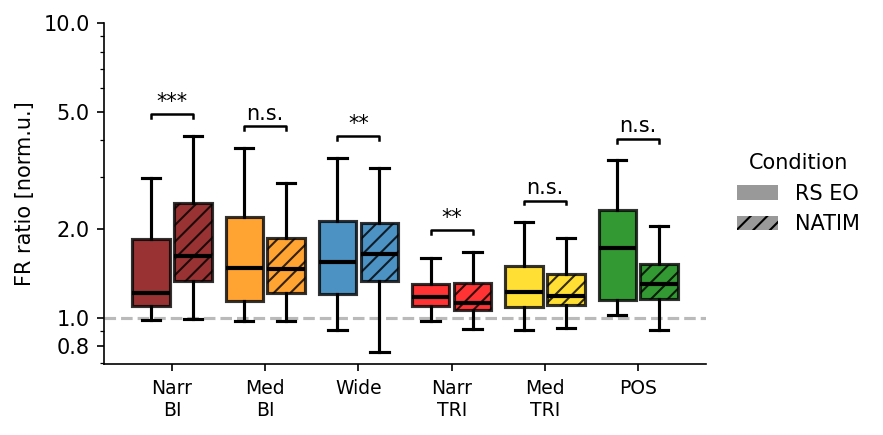

In [6]:
down_classes = ['DOWN_narrow_shallow', 'DOWN_medium_shallow', 'DOWN_wide','DOWN_narrow_sharp','DOWN_medium_sharp','UP']
colors_cl = ['maroon','darkorange','tab:blue','red','gold','green']

x_positions = np.arange(len(down_classes))
fig, ax = plt.subplots(figsize=(6, 3), dpi=150)

ax.axhline(1,ls='dashed',alpha=0.8,color='darkgray')

box_width = 0.4
pair_spacing = 0.05

for i, cls in enumerate(down_classes):

    RS_vals = df_RS.loc[df_RS['final_class'] == cls, 'FR_high_env_low_env_median_ratio_EO']
    NATIM_vals = df_NATIM.loc[df_NATIM['final_class'] == cls, 'FR_high_env_low_env_median_ratio']

    p_no_bonf = results_df.loc[results_df['class'] == cls, 'p_value'].iloc[0]

    if p_no_bonf < 0.001:
        star = '***'
    elif p_no_bonf < 0.01:
        star = '**'
    elif p_no_bonf < 0.05:
        star = '*'
    else:
        star = 'n.s.'

    data = [RS_vals, NATIM_vals]
    xs = [ x_positions[i] - (box_width/2 + pair_spacing/2),
          x_positions[i] + (box_width/2 + pair_spacing/2)] 
    # Create boxplot
    box = ax.boxplot(
        data,
        positions=xs,
        widths=box_width,
        patch_artist=True,
        tick_labels=['', ''],
        showfliers=False,   # no outliers
        boxprops=dict(facecolor='white', alpha=0.1,linewidth=1.5),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(color='black', linewidth=1.5),
        capprops=dict(color='black', linewidth=1.5)
    )

    # Colors + hatches
    colors = [colors_cl[i], colors_cl[i]]
    hatches = [None, '///']

    for patch, color, hatch in zip(box['boxes'], colors, hatches):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        patch.set_linewidth(1.5)
        if hatch is not None:
            patch.set_hatch(hatch)

    upper_whisker = max([w.get_ydata().max() for w in box['whiskers']])

    y_bar = upper_whisker * 1.15  # small offset above whisker
    x1, x2 = xs

    ax.plot([x1, x1, x2, x2],
            [y_bar, y_bar*1.03, y_bar*1.03, y_bar],
            color='black', linewidth=1.2)

    ax.text(np.mean(xs), y_bar*1.05, star,
            ha='center', va='bottom', fontsize=10)

# X labels
ax.set_xticks(x_positions)
ax.set_xticklabels(['Narr\nBI', 'Med\nBI', 'Wide', 'Narr\nTRI','Med\nTRI','POS'], fontsize=9)

ax.set_ylabel('FR ratio [norm.u.]')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


solid_patch = mpatches.Patch(
    facecolor='gray', alpha=0.8, label='RS EO'
)
hatched_patch = mpatches.Patch(
    facecolor='gray', alpha=0.8, hatch='///', label='NATIM'
)

# Place legend outside on the right
ax.legend(
    handles=[solid_patch, hatched_patch],
    title='Condition',
    title_fontsize=10,
    fontsize=10,
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)   # <<< outside the plot on the right
)

ax.set_yscale('log')
ax.set_yticks([0.8, 1, 2, 5, 10])
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

plt.tight_layout()
plt.show()


## Phase select testing

In [7]:
# testing at once
down_classes = ['DOWN_narrow_shallow', 'DOWN_medium_shallow', 'DOWN_wide','DOWN_narrow_sharp','DOWN_medium_sharp','UP']

results = []

for cls in down_classes:
    
    RS_vals = df_RS.loc[df_RS['final_class'] == cls,
                        'norm_RB_phase_selectivity_spikes_EO']
    
    NATIM_vals = df_NATIM.loc[df_NATIM['final_class'] == cls,
                              'norm_RB_phase_selectivity_spikes']
    
    # Mann–Whitney U test (RS < NATIM)
    u_stat, p_val = stats.mannwhitneyu(RS_vals, NATIM_vals, alternative='two-sided')
    
    results.append({
        'class': cls,
        'comparison': 'RS vs NATIM',
        'u_stat': u_stat,
        'p_value': p_val,
        'n_RS': len(RS_vals),
        'n_NATIM': len(NATIM_vals),
        'median_RS': RS_vals.median(),
        'median_NATIM': NATIM_vals.median()
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Bonferroni correction
results_df['p_bonf'] = multipletests(results_df['p_value'], method='bonferroni')[1]  # we will plot withou correction, because just RS VS NATIM

results_df


,class,comparison,u_stat,p_value,n_RS,n_NATIM,median_RS,median_NATIM,p_bonf
0,DOWN_narrow_shallow,RS vs NATIM,240912.0,1.125441e-20,342,2055,0.062522,0.140931,6.752648e-20
1,DOWN_medium_shallow,RS vs NATIM,1173980.0,1.143140e-08,893,3007,0.076017,0.091623,6.858839e-08
2,DOWN_wide,RS vs NATIM,717512.0,8.199330e-10,492,3517,0.075883,0.108362,4.919598e-09
3,DOWN_narrow_sharp,RS vs NATIM,163319.0,9.254049e-01,206,1592,0.024176,0.022665,1.000000e+00
4,DOWN_medium_sharp,RS vs NATIM,130477.0,1.019049e-01,225,1245,0.016854,0.020201,6.114294e-01
5,UP,RS vs NATIM,5287.0,6.566921e-03,28,288,0.211690,0.106450,3.940153e-02


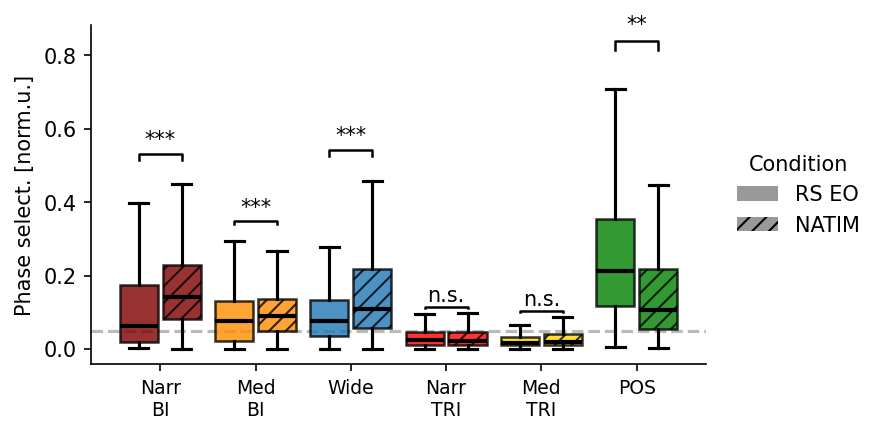

In [8]:
down_classes = ['DOWN_narrow_shallow', 'DOWN_medium_shallow', 'DOWN_wide','DOWN_narrow_sharp','DOWN_medium_sharp','UP']
colors_cl = ['maroon','darkorange','tab:blue','red','gold','green']

x_positions = np.arange(len(down_classes))
fig, ax = plt.subplots(figsize=(6, 3), dpi=150)

ax.axhline(0.05,ls='dashed',alpha=0.8,color='darkgray')

box_width = 0.4
pair_spacing = 0.05

for i, cls in enumerate(down_classes):
    RS_vals = df_RS.loc[df_RS['final_class'] == cls, 'norm_RB_phase_selectivity_spikes_EO']
    NATIM_vals = df_NATIM.loc[df_NATIM['final_class'] == cls, 'norm_RB_phase_selectivity_spikes']

    p_no_bonf = results_df.loc[results_df['class'] == cls, 'p_value'].iloc[0]

    if p_no_bonf < 0.001:
        star = '***'
    elif p_no_bonf < 0.01:
        star = '**'
    elif p_no_bonf < 0.05:
        star = '*'
    else:
        star = 'n.s.'

    data = [RS_vals, NATIM_vals]
    xs = [ x_positions[i] - (box_width/2 + pair_spacing/2),
          x_positions[i] + (box_width/2 + pair_spacing/2)] 
    # Create boxplot
    box = ax.boxplot(
        data,
        positions=xs,
        widths=box_width,
        patch_artist=True,
        tick_labels=['', ''],
        showfliers=False,   # no outliers
        boxprops=dict(facecolor='white', alpha=0.1,linewidth=1.5),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(color='black', linewidth=1.5),
        capprops=dict(color='black', linewidth=1.5)
    )

    # Colors + hatches
    colors = [colors_cl[i], colors_cl[i]]
    hatches = [None, '///']

    for patch, color, hatch in zip(box['boxes'], colors, hatches):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        patch.set_linewidth(1.2)
        if hatch is not None:
            patch.set_hatch(hatch)

    # --- FIX: use whisker top instead of raw max ---
    upper_whisker = max([w.get_ydata().max() for w in box['whiskers']])

    y_bar = upper_whisker * 1.15  # small offset above whisker
    x1, x2 = xs

    ax.plot([x1, x1, x2, x2],
            [y_bar, y_bar*1.03, y_bar*1.03, y_bar],
            color='black', linewidth=1.2)

    ax.text(np.mean(xs), y_bar*1.05, star,
            ha='center', va='bottom', fontsize=10)

# Log scale
#ax.set_yscale('log')

# X labels
ax.set_xticks(x_positions)
ax.set_xticklabels(['Narr\nBI', 'Med\nBI', 'Wide', 'Narr\nTRI','Med\nTRI','POS'], fontsize=9)

ax.set_ylabel('Phase select. [norm.u.]')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


solid_patch = mpatches.Patch(
    facecolor='gray', alpha=0.8, label='RS EO'
)
hatched_patch = mpatches.Patch(
    facecolor='gray', alpha=0.8, hatch='///', label='NATIM'
)

# Place legend outside on the right
ax.legend(
    handles=[solid_patch, hatched_patch],
    title='Condition',
    title_fontsize=10,
    fontsize=10,
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)   # <<< outside the plot on the right
)



plt.tight_layout()
plt.show()


## Dominance of NarrBI in modulation - NATIM

In [9]:
target = "DOWN_narrow_shallow"
other_classes = [cls for cls in ['DOWN_wide', 'DOWN_narrow_sharp', 'DOWN_medium_shallow','UP','DOWN_medium_sharp'] if cls != target]

results = []

g_target = df_NATIM.loc[
    df_NATIM['final_class'] == target,
    'FR_high_env_low_env_median_ratio'
]

for cls in other_classes:
    g_other = df_NATIM.loc[
        df_NATIM['final_class'] == cls,
        'FR_high_env_low_env_median_ratio'
    ]
    
    # directional test: target > other
    stat, p = mannwhitneyu(g_target, g_other, alternative="greater")
    results.append([target, cls, stat, p])

df_results = pd.DataFrame(results, columns=["Target", "Compared_to", "U", "p_raw"])

# Bonferroni correction
df_results["p_bonferroni"] = (df_results["p_raw"] * len(df_results)).clip(upper=1.0)

df_results


,Target,Compared_to,U,p_raw,p_bonferroni
0,DOWN_narrow_shallow,DOWN_wide,3784851.0,1.569206e-03,7.846028e-03
1,DOWN_narrow_shallow,DOWN_narrow_sharp,2787710.5,2.081027e-292,1.040513e-291
2,DOWN_narrow_shallow,DOWN_medium_shallow,3757860.5,1.985501e-39,9.927503e-39
3,DOWN_narrow_shallow,UP,412712.0,8.717282e-28,4.358641e-27
4,DOWN_narrow_shallow,DOWN_medium_sharp,2027748.0,1.932343e-175,9.661716e-175
